Description of the method explored in this notebook:

One other goal could be that we have a feature space in which there are only unknown objects - for example objects from alerts of one night of observation, so the feature space would change every night - and we want to know which among these are more likely to be of the positive class.

To do this, we take known objects from the positive class as inputs to the model to see what are their nearest neighbors in the feature space. If an output appears multiple times (an object that would be the neighbor of multiple inputs), we could treat it as a higher level of confidence that it is of the positive class.  
Again, the efficiency of this model relies on how well separated are objects from different classes in the feature space.

To measure the accuracy of this model, we add known objects from the positive class (different from the inputs) in the feature space and check how often they get selected by the model.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from magcvs_library.functions import tqdm2
import warnings
# Disabling FutureWarnings:
warnings.filterwarnings('ignore', category=FutureWarning)

# Feature names (without linear features):
feature_names = ['mean', 'weightedMean', 'std', 'median', 'amplitude', 'beyond1Std', 'cusum', 'IPR10',
                 'kurtosis', 'MPR40_5', 'MPR20_10', 'maxSlope', 'medianAbsDev', 'medianBRP10',
                 'percentAmplitude', 'meanVariance', 'andersonDarlingNorm', 'chi2', 'skew', 'stetsonK']

In [2]:
# The following paths should be changed accordingly. The data can be saved from the features_from_light_curves.ipynb notebook.
positive = pd.read_parquet('../../data/magcvs/features_g.parquet')
negative = pd.read_parquet('../../data/negative/features_g.parquet')

# Adding labels for each class:
positive['class'] = 'positive'
negative['class'] = 'negative'

# Normalizing features:
g_set = pd.concat([positive, negative]) # Grouping positive & negative together so that they are then normalized the same way.
g_set = normalize(g_set[feature_names], axis=0)
positive[feature_names] = g_set[:len(positive)]
negative[feature_names] = g_set[len(positive):]

In [3]:
# positive train will be in the feature space with negative objects
# positive test will be the input to the nearest neighbors algorithm
positive_train, positive_test = train_test_split(positive, train_size=.7, random_state=42)

In [4]:
def find_candidates(positive_train, positive_test, negative_sample, n_neighbors=5, candidate_threshold=1):

    # Building the feature space in which to find the candidates:
    feature_space = pd.concat([negative_sample, positive_train]).reset_index(drop=True)

    # Finding the nearest neighbors of positive objects:
    neigh = NearestNeighbors(n_neighbors=n_neighbors).fit(feature_space[feature_names])
    neighbors_distance, neighbors_indices = neigh.kneighbors(positive_test[feature_names])
    neighbors = feature_space.loc[neighbors_indices.flatten()]

    # Ids of the neighbors and the number of times each id appears:
    ids, counts = np.unique(neighbors['objectId'], return_counts=True)

    # Creating the DataFrame that will store the candidates:
    col = ['objectId', 'time_range (yr)', 'nb_of_points', 'class']
    candidates = pd.DataFrame(columns=[*col, 'count'])

    # Adding the candidates to the DataFrame:
    for id, count in zip(ids, counts):
        if count > candidate_threshold: # An object is considered as a candidate if it appears more than 'candidate_threshold' times in the neighbors
            candidate = neighbors[neighbors['objectId'] == id]
            new_row = pd.DataFrame([dict(zip(candidates.columns, [candidate['objectId'].values[0], candidate['time_range (yr)'].values[0], candidate['nb_of_points'].values[0], candidate['class'].values[0], count]))])
            candidates = pd.concat([candidates, new_row], ignore_index=True)

    # Computing the accuracy of candidates being of the positive class:
    pos_nb = 0
    for obj_class in candidates['class']:
        if obj_class == 'positive':
            pos_nb += 1
    if len(candidates) > 0:
        accuracy = pos_nb / len(candidates)
    else:
        accuracy = 0

    return candidates.reset_index(drop=True), accuracy

In [5]:
def candidates_mean_accuracy(negative_sample_size=30_000, n_neighbors=5, candidate_threshold=1):
    accuracies = []
    for i in tqdm2(range(100)):
        negative_sample = negative.sample(n=negative_sample_size)
        _, accuracy = find_candidates(positive_train, positive_test, negative_sample, n_neighbors=n_neighbors, candidate_threshold=candidate_threshold)
        accuracies.append(accuracy)
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    
    # print(f'Mean accuracy: ({mean_accuracy*100:.4f} +/- {std_accuracy*100:.4f}) %')
    
    return mean_accuracy, std_accuracy

In [6]:
def acc_vs_n_neigh(negative_sample_size=30_000, candidate_threshold=1, n_neighbors_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]):
    mean_accuracies = []
    for n_neighbors in n_neighbors_list:
        mean_accuracy, std_accuracy = candidates_mean_accuracy(negative_sample_size=negative_sample_size, n_neighbors=n_neighbors, candidate_threshold=candidate_threshold)
        mean_accuracies.append((mean_accuracy, std_accuracy))

    plt.errorbar(n_neighbors_list, [mean_accuracy[0]*100 for mean_accuracy in mean_accuracies], yerr=[mean_accuracy[1]*100 for mean_accuracy in mean_accuracies], fmt='o')
    plt.title(f'Mean accuracy versus number of neighbors\n{negative_sample_size} negative objects in the feature space, candidate threshold = {candidate_threshold}')
    plt.xlabel('Number of neighbors')
    plt.ylabel('Mean accuracy (%)')
    plt.xticks(n_neighbors_list)
    plt.ylim(bottom=0)
    plt.grid(axis='x')
    plt.axhline(y=50, color='r', linestyle='--', label='50% accuracy')
    plt.axhline(y=0, color='k', linestyle='--', label='0% accuracy')
    plt.legend(loc='upper right')
    plt.tight_layout()

100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100


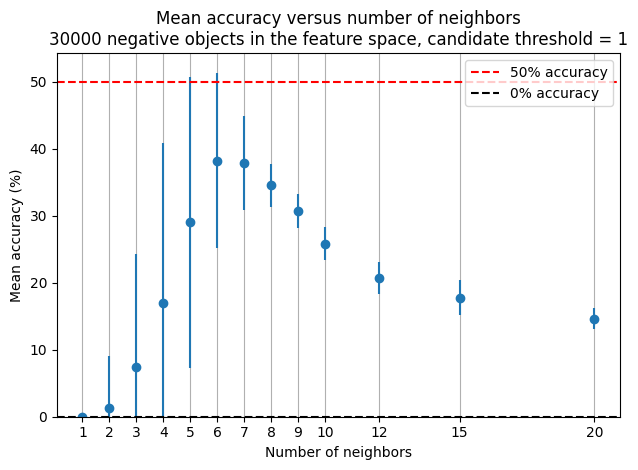

In [7]:
acc_vs_n_neigh()

100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100


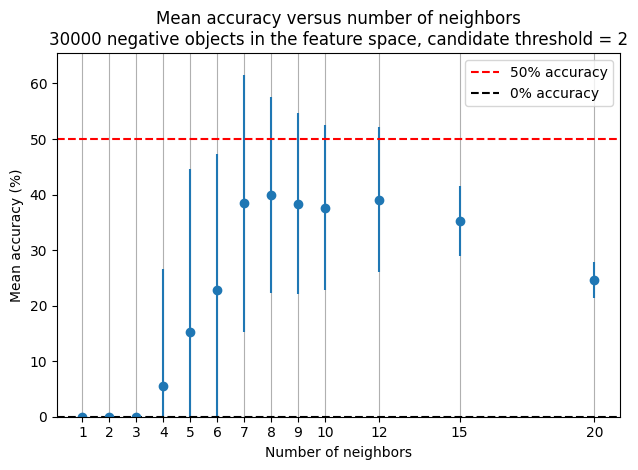

In [8]:
acc_vs_n_neigh(candidate_threshold=2)

100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100
100%|██████████| 100/100


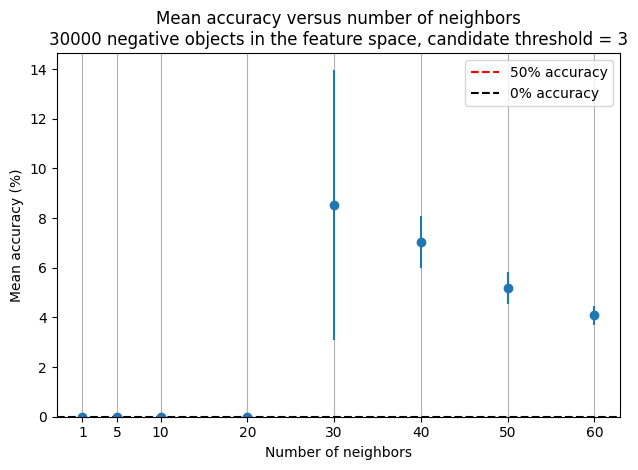

In [9]:
acc_vs_n_neigh(candidate_threshold=3, n_neighbors_list = [1, 5, 10, 20, 30, 40, 50, 60])